# 6. Análisis Exploratorio de Datos (EDA)

## Objetivo

En esta etapa se realiza un análisis exploratorio del conjunto de datos enriquecido obtenido tras el proceso de integración e ingeniería de variables.

El propósito es comprender la estructura del conjunto de datos, identificar la distribución de las variables, detectar valores atípicos, evaluar la presencia de datos faltantes y analizar las relaciones entre los principales indicadores educativos.

Este análisis permitirá comprender el comportamiento de los datos antes del entrenamiento de los modelos de aprendizaje automático y servirá como apoyo para la interpretación de los resultados obtenidos posteriormente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Ruta del proyecto
PROJECT_ROOT = Path.cwd().parent

# Cargar dataset enriquecido
df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "dataset_modelado.csv"
)

print(df.shape)
df.head()

(15707, 85)


,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,...,REPITENCIA_MEDIA_ETC,BENEFICIARIOS_PAE,BRECHA_COBERTURA,BRECHA_APROBACION,INDICE_EFICIENCIA,PRESION_SISTEMA,DIGITALIZADO,TAM_GRUPO_NORMALIZADO,PESO_MUNICIPIO_ETC,PANDEMIA
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499.0,56.11,56.11,...,3.35,NaN,5.81,99.36,11.418099,8.893245,0,NaN,0.001007,0
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862.0,95.33,95.33,...,3.21,NaN,96.18,91.52,6.821739,19.532151,0,NaN,0.011952,0
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239.0,50.70,50.70,...,4.08,NaN,7.04,64.06,1.940284,497.810651,0,NaN,0.750245,0
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157.0,81.42,81.42,...,4.08,NaN,9.16,78.44,3.176015,14.210268,0,NaN,0.034393,0
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645.0,90.96,90.96,...,4.08,NaN,8.17,77.18,3.169123,29.078716,0,NaN,0.078624,0


## 6.1 Información general del conjunto de datos

Como primer paso se inspecciona el tamaño del conjunto de datos, el tipo de cada variable y la cantidad de valores faltantes. Esta revisión permite verificar que la integración de las diferentes fuentes de información se realizó correctamente y proporciona una visión general de la calidad del conjunto de datos antes de realizar análisis más detallados.

In [2]:
print("="*60)
print("INFORMACIÓN GENERAL")
print("="*60)

print()

print(df.info())

print()

print(df.describe(include="all"))

INFORMACIÓN GENERAL

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15707 entries, 0 to 15706
Data columns (total 85 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   AÑO                              15707 non-null  int64  
 1   CÓDIGO_MUNICIPIO                 15707 non-null  int64  
 2   MUNICIPIO                        15707 non-null  object 
 3   CÓDIGO_DEPARTAMENTO              15707 non-null  int64  
 4   DEPARTAMENTO                     15707 non-null  object 
 5   CÓDIGO_ETC                       15707 non-null  float64
 6   ETC                              15707 non-null  object 
 7   POBLACIÓN_5_16                   15701 non-null  float64
 8   TASA_MATRICULACIÓN_5_16          15592 non-null  float64
 9   COBERTURA_NETA                   15596 non-null  float64
 10  COBERTURA_NETA_TRANSICIÓN        15655 non-null  float64
 11  COBERTURA_NETA_PRIMARIA          15616 non-null  float64
 1

## 6.2 Valores faltantes

Los valores faltantes constituyen un aspecto importante dentro del análisis exploratorio, ya que pueden influir en el entrenamiento de los modelos predictivos. En esta sección se calcula el porcentaje de datos ausentes para identificar aquellas variables que requerirán algún tratamiento durante la etapa de preprocesamiento o modelado.

In [3]:
faltantes = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      *100
)

faltantes = faltantes.to_frame("% Valores faltantes")

faltantes.head(20)

,% Valores faltantes
BENEFICIARIOS_PAE,81.435029
TAM_GRUPO_NORMALIZADO,51.792195
TAMAÑO_PROMEDIO_DE_GRUPO,51.792195
SEDES_CONECTADAS_A_INTERNET,50.544343
SEDES_CONECTADAS_A_INTERNET_ETC,50.028650
TAMAÑO_PROMEDIO_DE_GRUPO_ETC,50.022283
TASA_MATRICULACIÓN_5_16_ETC,14.318457
REPROBACIÓN_TRANSICIÓN_ETC,7.557140
REPROBACIÓN_SECUNDARIA_ETC,7.378876
REPROBACIÓN_PRIMARIA_ETC,7.372509


## 6.3 Distribución de la deserción escolar

La deserción escolar constituye uno de los indicadores centrales del proyecto. Analizar su distribución permite identificar la concentración de municipios con niveles bajos, medios o altos de abandono escolar, así como detectar posibles valores atípicos que puedan influir en el entrenamiento de los modelos predictivos.

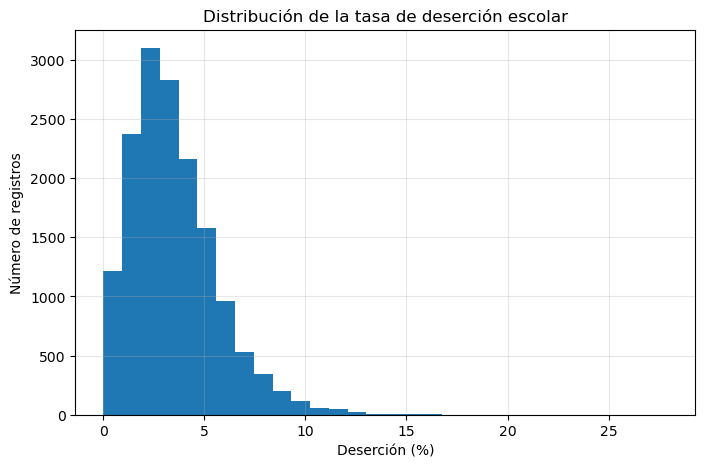

count    15565.000000
mean         3.485402
std          2.146110
min          0.000000
25%          1.950000
50%          3.150000
75%          4.640000
max         27.900000
Name: DESERCIÓN, dtype: float64


In [4]:
plt.figure(figsize=(8,5))

plt.hist(
    df["DESERCIÓN"].dropna(),
    bins=30
)

plt.title("Distribución de la tasa de deserción escolar")
plt.xlabel("Deserción (%)")
plt.ylabel("Número de registros")

plt.grid(alpha=0.3)

plt.show()

print(df["DESERCIÓN"].describe())

## 6.4 Evolución temporal de la deserción escolar

Además de analizar la distribución general de la deserción, resulta importante estudiar su comportamiento a lo largo del tiempo. Para ello se calcula el promedio anual de la tasa de deserción considerando todos los municipios disponibles en cada año.

Este análisis permite identificar tendencias generales, así como posibles cambios asociados a eventos externos, como la pandemia por COVID-19.

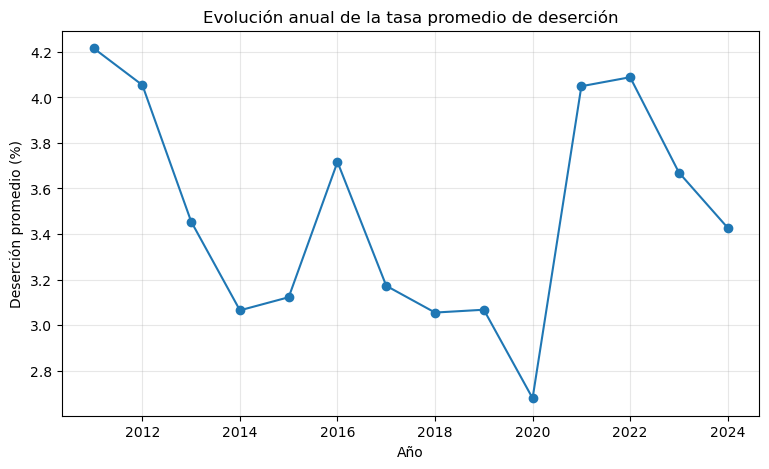

AÑO
2011    4.216292
2012    4.054294
2013    3.454746
2014    3.064640
2015    3.122206
2016    3.716527
2017    3.172321
2018    3.054857
2019    3.067280
2020    2.678479
2021    4.049292
2022    4.088894
2023    3.670080
2024    3.427308
Name: DESERCIÓN, dtype: float64

In [5]:
# Promedio anual de deserción
desercion_anual = (
    df.groupby("AÑO")["DESERCIÓN"]
      .mean()
)

plt.figure(figsize=(9,5))

plt.plot(
    desercion_anual.index,
    desercion_anual.values,
    marker="o"
)

plt.title("Evolución anual de la tasa promedio de deserción")
plt.xlabel("Año")
plt.ylabel("Deserción promedio (%)")

plt.grid(alpha=0.3)

plt.show()

desercion_anual

### Interpretación

La evolución temporal de la tasa promedio de deserción escolar muestra una tendencia general de disminución entre los años 2011 y 2020, aunque con algunas fluctuaciones intermedias.

A partir de 2021 se observa un incremento considerable en la deserción promedio, alcanzando sus valores más altos durante los años 2021 y 2022. Este comportamiento coincide temporalmente con el periodo posterior a la pandemia por COVID-19, lo que sugiere un posible impacto de este evento sobre la permanencia de los estudiantes en el sistema educativo.

Finalmente, durante los años 2023 y 2024 se evidencia nuevamente una reducción de la tasa promedio de deserción, lo que podría indicar un proceso de recuperación progresiva del sistema educativo. Sin embargo, se requieren análisis posteriores para establecer relaciones causales entre estos eventos y el comportamiento observado.

## 6.5 Correlación entre variables

Con el fin de identificar posibles relaciones lineales entre las variables del conjunto de datos, se calcula una matriz de correlación utilizando los principales indicadores educativos y las variables derivadas durante la etapa de ingeniería de características.

Este análisis permite detectar asociaciones positivas o negativas entre los indicadores, así como posibles problemas de multicolinealidad que podrían afectar el desempeño de algunos modelos de aprendizaje automático.

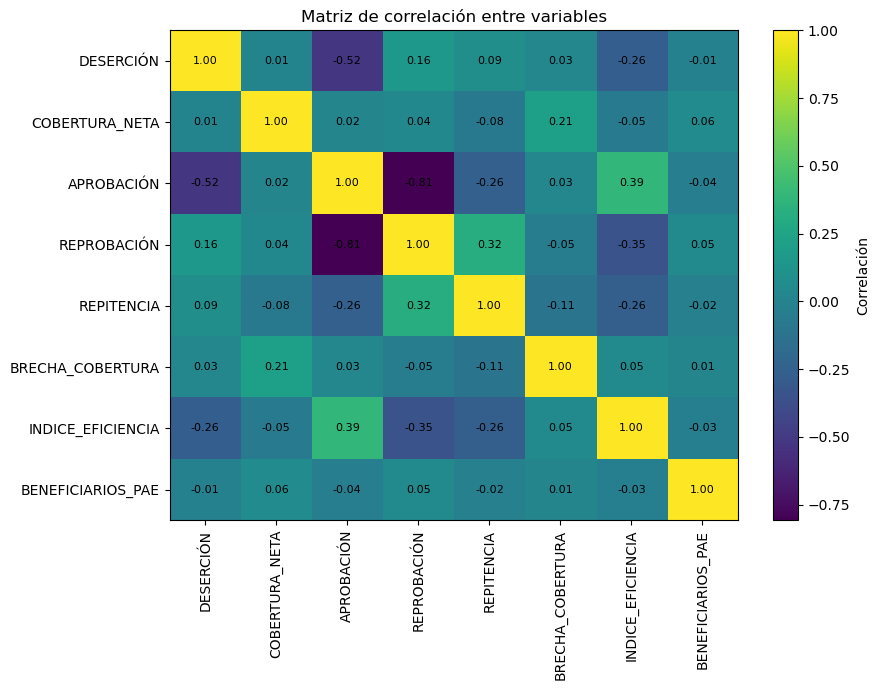

,DESERCIÓN,COBERTURA_NETA,APROBACIÓN,REPROBACIÓN,REPITENCIA,BRECHA_COBERTURA,INDICE_EFICIENCIA,BENEFICIARIOS_PAE
DESERCIÓN,1.000000,0.008628,-0.519418,0.157600,0.089141,0.029116,-0.264612,-0.011555
COBERTURA_NETA,0.008628,1.000000,0.016570,0.035330,-0.078261,0.213574,-0.052534,0.063852
APROBACIÓN,-0.519418,0.016570,1.000000,-0.806975,-0.255620,0.027562,0.391709,-0.035671
REPROBACIÓN,0.157600,0.035330,-0.806975,1.000000,0.321029,-0.046872,-0.345516,0.050824
REPITENCIA,0.089141,-0.078261,-0.255620,0.321029,1.000000,-0.112871,-0.262386,-0.018188
BRECHA_COBERTURA,0.029116,0.213574,0.027562,-0.046872,-0.112871,1.000000,0.050517,0.013008
INDICE_EFICIENCIA,-0.264612,-0.052534,0.391709,-0.345516,-0.262386,0.050517,1.000000,-0.029141
BENEFICIARIOS_PAE,-0.011555,0.063852,-0.035671,0.050824,-0.018188,0.013008,-0.029141,1.000000


In [6]:
variables = [
    "DESERCIÓN",
    "COBERTURA_NETA",
    "APROBACIÓN",
    "REPROBACIÓN",
    "REPITENCIA",
    "BRECHA_COBERTURA",
    "INDICE_EFICIENCIA",
    "BENEFICIARIOS_PAE"
]

corr = df[variables].corr(numeric_only=True)

plt.figure(figsize=(9,7))

plt.imshow(corr, aspect="auto")

plt.colorbar(label="Correlación")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Mostrar los valores de correlación
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Matriz de correlación entre variables")

plt.tight_layout()

plt.show()

corr

### Interpretación

La matriz de correlación permite observar la relación lineal existente entre las principales variables educativas incluidas en el conjunto de datos.

Se evidencia una fuerte correlación negativa entre las variables de **aprobación** y **reprobación**, lo cual resulta consistente con el comportamiento esperado del sistema educativo: a medida que aumenta la aprobación, disminuye la reprobación.

La **deserción escolar** presenta correlaciones moderadas con variables como la aprobación, la repitencia y la reprobación, lo que indica que estos indicadores podrían aportar información relevante para los modelos predictivos.

Por otra parte, variables como los **beneficiarios del PAE** muestran una correlación lineal relativamente baja con el resto de indicadores. Esto no implica necesariamente que carezcan de capacidad predictiva, ya que algunos algoritmos de aprendizaje automático son capaces de capturar relaciones no lineales entre las variables.

En términos generales, no se observan niveles elevados de correlación positiva entre la mayoría de variables, lo que reduce el riesgo de problemas de multicolinealidad en los modelos posteriores.

## 6.6 Distribución de la brecha de cobertura

Durante la etapa de ingeniería de características se construyó la variable **Brecha de Cobertura**, definida como la diferencia entre la cobertura bruta y la cobertura neta.

Esta variable permite aproximar el nivel de extraedad y repitencia presente en cada municipio, ya que una mayor diferencia entre ambas coberturas suele indicar una mayor proporción de estudiantes matriculados fuera de la edad esperada para su grado.

Analizar su distribución permite comprender cómo se comporta este indicador a nivel nacional e identificar posibles valores atípicos.

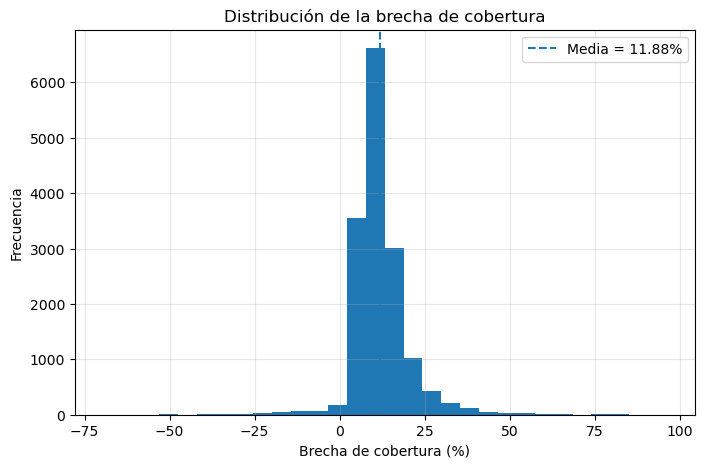

count    15575.000000
mean        11.880832
std          9.106683
min        -69.580000
25%          7.690000
50%         10.700000
75%         14.670000
max         96.180000
Name: BRECHA_COBERTURA, dtype: float64


In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    df["BRECHA_COBERTURA"].dropna(),
    bins=30
)

media = df["BRECHA_COBERTURA"].mean()

plt.axvline(
    media,
    linestyle="--",
    label=f"Media = {media:.2f}%"
)

plt.title("Distribución de la brecha de cobertura")
plt.xlabel("Brecha de cobertura (%)")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

print(df["BRECHA_COBERTURA"].describe())

### Interpretación

La distribución de la variable **Brecha de Cobertura** presenta una marcada concentración entre aproximadamente el 5 % y el 20 %, con un valor promedio cercano al 11,9 %. Esto indica que, para la mayoría de los municipios y años analizados, la cobertura bruta supera a la cobertura neta en una magnitud moderada.

Asimismo, se observan algunos valores extremos tanto positivos como negativos. Las brechas positivas elevadas pueden estar asociadas a una mayor presencia de estudiantes en condición de extraedad o repitencia, mientras que las brechas negativas representan un porcentaje reducido de los registros y podrían estar relacionadas con procesos de estimación estadística o inconsistencias en la información reportada.

En general, la distribución obtenida confirma que la variable presenta suficiente variabilidad para ser considerada como un posible predictor en los modelos de aprendizaje automático desarrollados en este proyecto.

## 6.7 Municipios con mayor tasa de deserción escolar en 2024

Con el fin de identificar los territorios con mayores desafíos en materia de permanencia escolar, se seleccionan los municipios que registraron las tasas de deserción más altas durante el año 2024.

Este análisis permite visualizar los casos más críticos dentro del conjunto de datos y constituye un insumo importante para la priorización de intervenciones y políticas públicas orientadas a reducir el abandono escolar.

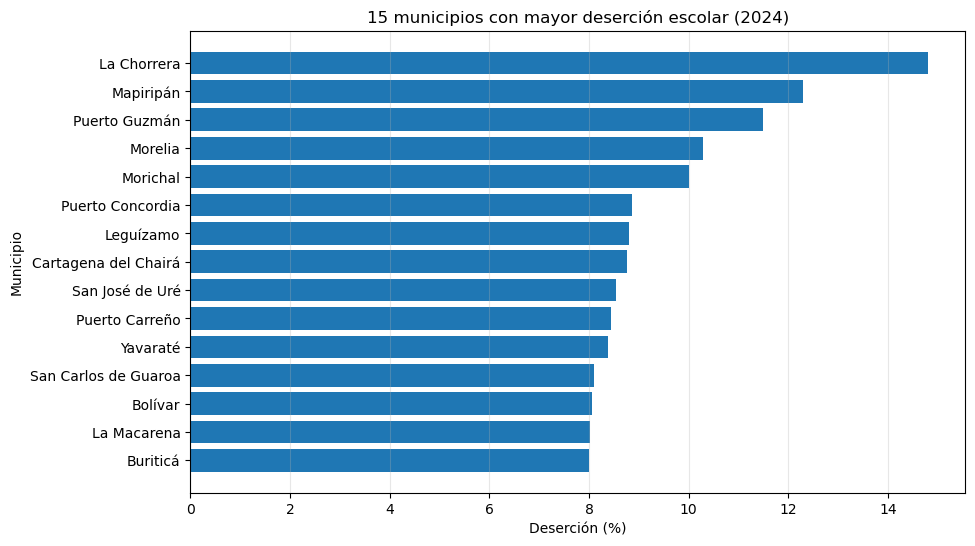

,MUNICIPIO,DEPARTAMENTO,DESERCIÓN
32,La Chorrera,Amazonas,14.81
425,Mapiripán,Meta,12.29
44,Puerto Guzmán,Putumayo,11.50
772,Morelia,Caquetá,10.28
16,Morichal,Guainía,10.00
420,Puerto Concordia,Meta,8.87
43,Leguízamo,Putumayo,8.81
778,Cartagena del Chairá,Caquetá,8.76
674,San José de Uré,Córdoba,8.54
5,Puerto Carreño,Vichada,8.45


In [8]:
# Filtrar únicamente el año más reciente
top_desercion = (
    df[df["AÑO"] == 2024]
    .sort_values("DESERCIÓN", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_desercion["MUNICIPIO"],
    top_desercion["DESERCIÓN"]
)

plt.title("15 municipios con mayor deserción escolar (2024)")
plt.xlabel("Deserción (%)")
plt.ylabel("Municipio")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.show()

top_desercion[
    ["MUNICIPIO","DEPARTAMENTO","DESERCIÓN"]
]

### Interpretación

El análisis de los municipios con mayor tasa de deserción escolar durante 2024 evidencia que los valores más elevados se concentran principalmente en territorios pertenecientes a las regiones Amazónica y de la Orinoquía colombiana.

Municipios como **La Chorrera (Amazonas)**, **Mapiripán (Meta)** y **Puerto Guzmán (Putumayo)** presentan las tasas más altas de deserción dentro del conjunto de datos analizado. Asimismo, se observa la presencia recurrente de municipios pertenecientes a departamentos como Meta, Putumayo y Caquetá.

Esta distribución sugiere que la deserción escolar podría estar asociada a factores territoriales como la dispersión geográfica, las dificultades de acceso a los establecimientos educativos, las condiciones socioeconómicas y las limitaciones en infraestructura presentes en estas regiones. No obstante, establecer relaciones causales requiere análisis adicionales que exceden el alcance del presente estudio.

La identificación de estos municipios constituye un insumo valioso para orientar estrategias de focalización y priorización de políticas públicas encaminadas a mejorar la permanencia escolar.

# Conclusiones del análisis exploratorio

El análisis exploratorio permitió verificar la calidad del conjunto de datos integrado y comprender el comportamiento general de las principales variables educativas.

Entre los principales hallazgos se identificó que la tasa de deserción escolar presenta una distribución concentrada en valores bajos, aunque con la presencia de algunos municipios que registran niveles considerablemente superiores al promedio nacional. Asimismo, se observó un incremento de la deserción durante los años posteriores a la pandemia, seguido de una tendencia de recuperación en los años más recientes.

La matriz de correlación evidenció relaciones coherentes entre los principales indicadores educativos, mientras que la variable **Brecha de Cobertura**, desarrollada durante la etapa de ingeniería de características, mostró una distribución adecuada y suficiente variabilidad para ser considerada en los modelos predictivos.

Finalmente, la identificación de los municipios con mayores tasas de deserción permitió evidenciar una concentración geográfica en regiones de difícil acceso, lo que resalta la importancia del contexto territorial dentro del análisis del fenómeno educativo.

En conjunto, los resultados obtenidos proporcionan una base sólida para la etapa de entrenamiento y evaluación de los modelos de aprendizaje automático, desarrollada en el siguiente módulo.